In [8]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [9]:
from textblob import TextBlob

print(TextBlob("I love Python").sentiment)

Sentiment(polarity=0.5, subjectivity=0.6)


In [10]:
import pandas as pd

# sample dataset (we will simulate for learning)
data = {
    "review": [
        "This product is amazing, I love it",
        "Very bad quality, waste of money",
        "It's okay not too good not too bad",
        "Excellent product, highly recommended",
        "Worst experience ever"
    ]
}

df = pd.DataFrame(data)

print(df)

                                  review
0     This product is amazing, I love it
1       Very bad quality, waste of money
2     It's okay not too good not too bad
3  Excellent product, highly recommended
4                  Worst experience ever


In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df["clean_review"] = df["review"].apply(clean_text)

print(df)

                                  review                          clean_review
0     This product is amazing, I love it     this product is amazing i love it
1       Very bad quality, waste of money       very bad quality waste of money
2     It's okay not too good not too bad     its okay not too good not too bad
3  Excellent product, highly recommended  excellent product highly recommended
4                  Worst experience ever                 worst experience ever


In [12]:
from textblob import TextBlob

def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["clean_review"].apply(get_sentiment)

print(df)

                                  review  \
0     This product is amazing, I love it   
1       Very bad quality, waste of money   
2     It's okay not too good not too bad   
3  Excellent product, highly recommended   
4                  Worst experience ever   

                           clean_review sentiment  
0     this product is amazing i love it  Positive  
1       very bad quality waste of money  Negative  
2     its okay not too good not too bad  Positive  
3  excellent product highly recommended  Positive  
4                 worst experience ever  Negative  


In [13]:
print(df["sentiment"].value_counts())

sentiment
Positive    3
Negative    2
Name: count, dtype: int64


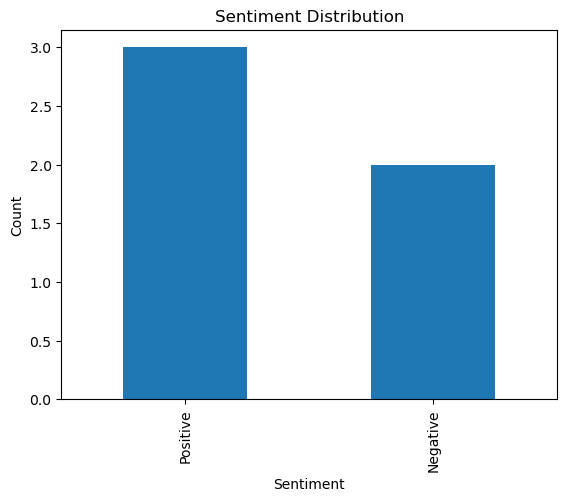

In [14]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

## Insights

1. Most reviews are positive, indicating good customer satisfaction.
2. Negative reviews highlight product quality issues.
3. Neutral reviews indicate mixed customer experience.
4. Sentiment analysis helps understand customer opinion trends.

## Conclusion

Sentiment analysis was performed on text reviews to classify them into positive, negative, and neutral categories.
The analysis helps understand customer opinions and can be used for improving products, marketing strategies, and business decisions.